(17396, 5) 6080


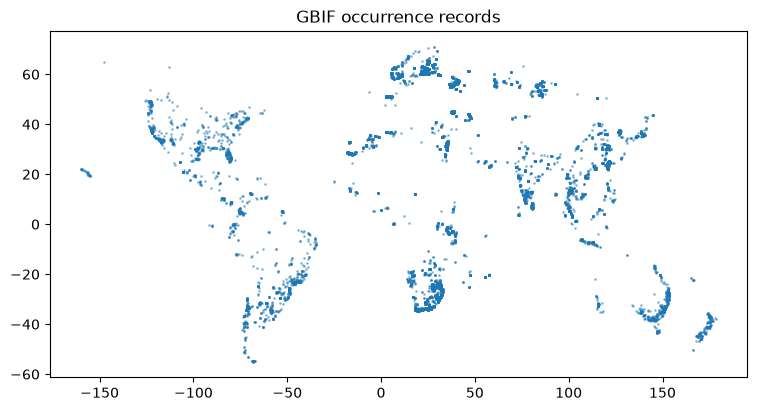

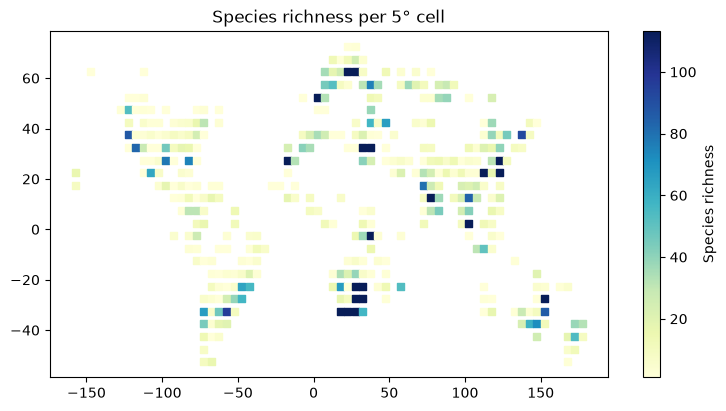

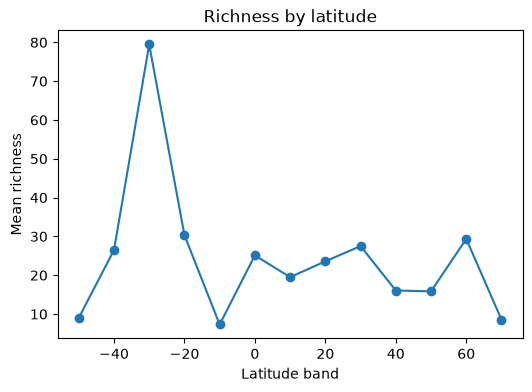

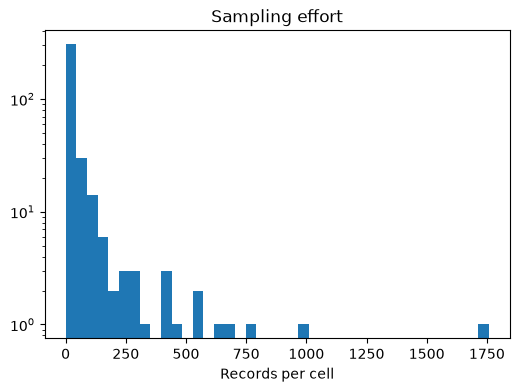

In [1]:
import sys
sys.path.append("..")

from common.helpers import *


# If all_continents.csv is just the merge of the 6 files, use it; else pd.concat the 6 files
df = add_cell(load_gbif("raw/gbif_all_continents.csv"))

print(df.shape, df.species.nunique())

df.to_csv(
    "processed/gbif_points_clean.csv",
    index=False
)


cells = df.groupby(
    ["cell_lat", "cell_lon"]
).agg(
    richness=("species", "nunique"),
    n_records=("species", "size")
).reset_index()

cells.to_csv(
    "processed/gbif_richness_cells.csv",
    index=False
)


# Table
summary = pd.DataFrame({
    "records": [len(df)],
    "species": [df.species.nunique()],
    "cells": [len(cells)],
    "median_richness": [cells.richness.median()],
    "max_richness": [cells.richness.max()]
})

summary.to_csv(
    "processed/gbif_summary.csv",
    index=False
)

cells.sort_values(
    "richness",
    ascending=False
).head(10).to_csv(
    "processed/gbif_top10_cells.csv",
    index=False
)


# Fig 1: records map
plt.figure(figsize=(9, 4.5))

plt.scatter(
    df.lon,
    df.lat,
    s=1,
    alpha=.4
)

plt.title("GBIF occurrence records")

plt.savefig(
    "figures/gbif_records_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Fig 2: richness map
plt.figure(figsize=(9, 4.5))

sc = plt.scatter(
    cells.cell_lon,
    cells.cell_lat,
    c=cells.richness,
    s=25,
    cmap="YlGnBu",
    marker="s",
    vmax=cells.richness.quantile(.95)
)

plt.colorbar(
    sc,
    label="Species richness"
)

plt.title(f"Species richness per {CELL}° cell")

plt.savefig(
    "figures/gbif_richness_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Fig 3: richness vs latitude
lat = cells.groupby(
    cells.cell_lat.round(-1)
).richness.mean()

plt.figure(figsize=(6, 4))

lat.plot(marker="o")

plt.xlabel("Latitude band")
plt.ylabel("Mean richness")
plt.title("Richness by latitude")

plt.savefig(
    "figures/gbif_richness_latitude.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Fig 4: sampling effort
plt.figure(figsize=(6, 4))

plt.hist(
    cells.n_records,
    bins=40,
    log=True
)

plt.xlabel("Records per cell")
plt.title("Sampling effort")

plt.savefig(
    "figures/gbif_records_per_cell.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [2]:
# ---------- Numbers for notes.md ----------

print("Grid:", CELL, "degrees")
print("Clean records:", len(df), "| Unique species:", df.species.nunique())
print("Cells:", len(cells))

print(
    "Richness  -> median:", cells.richness.median(),
    "| mean:", round(cells.richness.mean(), 1),
    "| max:", cells.richness.max()
)

print(
    "Records/cell -> median:", cells.n_records.median(),
    "| mean:", round(cells.n_records.mean(), 1),
    "| max:", cells.n_records.max()
)

print(
    "Cells with >= 10 records:", int((cells.n_records >= 10).sum()),
    "| >= 20:", int((cells.n_records >= 20).sum()),
    "| < 10:", int((cells.n_records < 10).sum())
)


print("\nTop 10 richest cells:")
print(
    cells.sort_values(
        "richness",
        ascending=False
    ).head(10).to_string(index=False)
)


print("\nMean richness by latitude band:")
print(
    cells.groupby(
        cells.cell_lat.round(-1)
    ).richness.agg(
        ["mean", "count"]
    ).round(1).to_string()
)


print("\nRecords by continent file (check against raw files):")

import glob

for f in sorted(glob.glob("raw/gbif_*_*.csv")):
    print(
        os.path.basename(f),
        len(pd.read_csv(
            f,
            sep=None,
            engine="python",
            on_bad_lines="skip"
        ))
    )


print("\nSummary table:")
print(
    pd.read_csv(
        "processed/gbif_summary.csv"
    ).to_string(index=False)
)

Grid: 5 degrees
Clean records: 17396 | Unique species: 6080
Cells: 375
Richness  -> median: 9.0 | mean: 26.6 | max: 453
Records/cell -> median: 10.0 | mean: 46.4 | max: 1757
Cells with >= 10 records: 188 | >= 20: 125 | < 10: 187

Top 10 richest cells:
 cell_lat  cell_lon  richness  n_records
    -27.5      32.5       453        619
    -32.5      17.5       451        756
    -22.5      32.5       437        662
    -27.5      27.5       373        556
     22.5     122.5       312        422
      2.5     102.5       289        445
    -32.5      27.5       240        351
    -32.5      22.5       224        302
     27.5     -17.5       195        301
     27.5     122.5       170        224

Mean richness by latitude band:
          mean  count
cell_lat             
-50.0      9.0      6
-40.0     26.5     17
-30.0     79.5     31
-20.0     30.3     34
-10.0      7.3     23
-0.0      25.1     26
 10.0     19.5     36
 20.0     23.6     41
 30.0     27.5     53
 40.0     16.1     49
